# De Novo Inhibitor Generation with Guardrails

*Turning a QSAR activity model into a molecular generator, and building the guardrails that keep generated molecules realistic: applicability domain, novelty, drug-likeness, synthesizability and structural alerts.*

## Abstract

The QSAR models of the previous notebooks predict activity; here one of them (EGFR) is turned into the fitness function of a genetic algorithm that evolves molecules toward high predicted pIC50. Left unconstrained, the optimizer exploits the model's blind spots: it produces a molecule scored higher than a real drug (predicted pIC50 7.96 vs 7.51 for gefitinib) but chemically implausible (QED 0.16) and far outside the training domain (Tanimoto 0.25). Adding guardrails as a multiplicative multi-objective score (activity x drug-likeness x novelty-band x synthesizability x structural-alert filters) progressively fixes this, yielding a candidate that is drug-like (QED ~0.9), easy to synthesize (SA ~2.8), novel yet in-domain (Tanimoto ~0.35), and that rediscovers the quinazoline/anilino pharmacophore of real EGFR inhibitors. The notebook illustrates that in generative design, the scoring function and its guardrails matter more than the generator itself.

## 1. Introduction

De novo molecular design turns prediction into generation: instead of scoring existing molecules, we search chemical space for new ones that optimize an objective. Here the objective is provided by a QSAR model from the previous notebook (EGFR activity), used as an oracle. A genetic algorithm evolves a population of molecules toward high predicted activity.

The central risk is reward hacking: a predictive model is only reliable within its applicability domain, so an optimizer free to roam chemical space will find molecules that the model scores highly but that are out-of-domain, chemically unstable, or impossible to synthesize. The model's high score is then an extrapolation artifact, not a real prediction. This notebook builds the generator and then the guardrails that constrain it, treating each guardrail as a component of a multiplicative desirability score so that a molecule must satisfy all criteria at once.

## 2. Methods

### 2.1 The oracle and the fitness function

The per-target XGBoost models trained in notebook 06 are loaded; the EGFR model serves as the fitness function (predicted pIC50). Featurization is identical to the earlier notebooks (2048-bit ECFP4 + 7 descriptors).

In [ ]:
import numpy as np
import joblib
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "LogP": Descriptors.MolLogP(mol),
        "MolWt": Descriptors.MolWt(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "NumRotatableBonds": Descriptors.NumRotatableBonds(mol),
    }

def compute_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits))

def featurize_one(smiles):
    fp = compute_fingerprint(smiles)
    desc = compute_descriptors(smiles)
    if fp is None or desc is None:
        return None
    return np.hstack([fp, list(desc.values())]).reshape(1, -1).astype(np.float32)

models = joblib.load("../models/target_models.joblib")
ref_smiles = joblib.load("../models/train_smiles.joblib")
print("targets available:", list(models.keys()))

TARGET = "EGFR"
oracle = models[TARGET]

def fitness(smiles):
    x = featurize_one(smiles)
    if x is None:
        return None
    return float(oracle.predict(x)[0])

print("gefitinib (EGFR inhibitor):", round(fitness("COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1"), 2))
print("aspirin (control):        ", round(fitness("CC(=O)Oc1ccccc1C(=O)O"), 2))

targets available: ['hERG', 'BACE1', 'EGFR', 'CDK2', 'JAK2', 'PARP1', 'BRD4', 'Aurora A', 'PIK3CA']
gefitinib (EGFR inhibitor): 7.51
aspirin (control):         4.2


The oracle is usable as a fitness function: it scores a known EGFR inhibitor (gefitinib, 7.51) well above a non-inhibitor control (aspirin, 4.2).

### 2.2 Mutation with SELFIES

Mutations operate on SELFIES strings rather than SMILES: every SELFIES string decodes to a valid molecule, so mutation (replacing, inserting or deleting a token) never produces an invalid structure. This removes the need to handle broken SMILES and greatly simplifies the genetic algorithm.

In [ ]:
import selfies as sf
import random

ALPHABET = list(sf.get_semantic_robust_alphabet())   

def mutate(smiles, n_mut=1):
    try:
        tokens = list(sf.split_selfies(sf.encoder(smiles)))
    except Exception:
        return None
    for _ in range(n_mut):
        if not tokens:
            break
        op = random.choice(["replace", "insert", "delete"])
        i = random.randrange(len(tokens))
        if op == "replace":
            tokens[i] = random.choice(ALPHABET)
        elif op == "insert":
            tokens.insert(i, random.choice(ALPHABET))
        elif op == "delete" and len(tokens) > 1:
            tokens.pop(i)
    try:
        return sf.decoder("".join(tokens))   
    except Exception:
        return None

All five mutants are valid molecules with varied fitness, confirming the SELFIES-based operator. Note that some carry unusual charged atoms: SELFIES guarantees a parseable molecule, not a chemically realistic one, which the guardrails will later address.

## 3. Naive generation and the reward-hacking pitfall

A first genetic algorithm uses predicted pIC50 alone as the fitness. The population is initialised from real (drug-like) training molecules; each generation keeps the top individuals and regenerates the rest by mutation.

In [10]:
parent = "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1"
for _ in range(5):
    child = mutate(parent, n_mut=2)
    print(round(fitness(child), 2) if child else "invalid", "|", child)

5.73 | C1OC=CC=NC=NC1(NC2=CC=C(F)C(Cl)=C2)C=COCCCNC3C[S+1]OCC3
6.07 | COC=C1C=NCC(NC2=CC=C(F)C(Cl)=C2)=C1C=COCCN3CCOCC3
6.06 | C12OC=CC=NC=NC1(N[P+1]=CC=C(C)CCl)C=C2OCCCN3CCOCC3
5.72 | COC=CC=NC=NC(NC=CC=C(F)C#[C+1])CC=COCCN1CCOCC1
5.8 | COC=CC=NC=NC1(NC=CC=C(F)C1(C)C)C=COCC2CN(O)CC2


In [ ]:
def score(smiles):
    if smiles is None:
        return -np.inf
    f = fitness(smiles)
    return f if f is not None else -np.inf

pop = random.sample(ref_smiles, 100)

n_gen, pop_size, n_keep = 20, 100, 20
history = []
for gen in range(n_gen):
    ranked = sorted(pop, key=score, reverse=True)
    parents = ranked[:n_keep]                 
    history.append(score(parents[0]))
    children = []
    while len(children) < pop_size - n_keep:  
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None:
            children.append(c)
    pop = parents + children                   
    print("gen", gen, "| best predicted pIC50:", round(history[-1], 2))

best = sorted(pop, key=score, reverse=True)[0]
print("\nBEST:", round(score(best), 2), "|", best)

gen 0 | best predicted pIC50: 8.23
gen 1 | best predicted pIC50: 8.23
gen 2 | best predicted pIC50: 8.23
gen 3 | best predicted pIC50: 8.23
gen 4 | best predicted pIC50: 8.27
gen 5 | best predicted pIC50: 8.34
gen 6 | best predicted pIC50: 8.34
gen 7 | best predicted pIC50: 8.34
gen 8 | best predicted pIC50: 8.34
gen 9 | best predicted pIC50: 8.55
gen 10 | best predicted pIC50: 8.55
gen 11 | best predicted pIC50: 8.55
gen 12 | best predicted pIC50: 8.55
gen 13 | best predicted pIC50: 8.55
gen 14 | best predicted pIC50: 8.66
gen 15 | best predicted pIC50: 8.66
gen 16 | best predicted pIC50: 8.66
gen 17 | best predicted pIC50: 8.66
gen 18 | best predicted pIC50: 8.66
gen 19 | best predicted pIC50: 8.66

BEST: 8.66 | [B-1]#CCC[C-1][C@@H1][S-1](NC1=C(C#N)C=NC2=C(C#N)C=C(N[C@H1](C3=CN(CCC)NN3)C4=CSC=C4C#[S+1]5CN5CCOC)C=C12)C=CC=CC#C


In [12]:
from rdkit.Chem import QED

def max_tanimoto(smiles, ref, n=2000):
    q = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smiles), 2, 2048)
    samp = random.sample(ref, min(n, len(ref)))
    fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)
           for s in samp if (m := Chem.MolFromSmiles(s)) is not None]
    return max(DataStructs.BulkTanimotoSimilarity(q, fps))

def qed(smiles):
    m = Chem.MolFromSmiles(smiles)
    return QED.qed(m) if m else None

for label, smi in [("generated best", best),
                   ("gefitinib (ref)", "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1")]:
    print(label)
    print("  predicted pIC50:", round(score(smi), 2))
    print("  max Tanimoto to training set:", round(max_tanimoto(smi, ref_smiles), 2))
    print("  QED (drug-likeness, 0-1):", round(qed(smi), 2))

generated best
  predicted pIC50: 8.66
  max Tanimoto to training set: 0.33
  QED (drug-likeness, 0-1): 0.02
gefitinib (ref)
  predicted pIC50: 7.51
  max Tanimoto to training set: 0.75
  QED (drug-likeness, 0-1): 0.52


The best predicted pIC50 climbs above that of gefitinib. Optimizing predicted activity alone therefore appears to "work". Yet, inspection is needed considering the drug-likeness and the Tanimoto similarity.

The generated champion has a higher predicted pIC50 than gefitinib (7.96 vs 7.51), yet its drug-likeness is very low (QED 0.16 vs 0.52) and its maximum Tanimoto similarity to the training set is only 0.25, against 0.82 for gefitinib. The molecule lies outside the applicability domain, so the oracle's high score is an extrapolation artifact: the optimizer has exploited the model's blind spots rather than found a genuine inhibitor. This motivates constraining the search.

## 4. Guardrails

Guardrails are combined as a multiplicative desirability score: each criterion is mapped to [0, 1] and the components are multiplied, so that a molecule failing any single criterion receives a near-zero score. This is stricter than a weighted sum, where a high activity could compensate for an implausible structure.

### 4.1 Applicability domain

The first guardrail multiplies the activity desirability by drug-likeness (QED) and by the maximum Tanimoto similarity to the training set (an applicability-domain proxy).

In [ ]:
REF_FPS = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)
           for s in random.sample(ref_smiles, 2000) if (m := Chem.MolFromSmiles(s)) is not None]

def ad_similarity(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return 0.0
    q = AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)
    return max(DataStructs.BulkTanimotoSimilarity(q, REF_FPS))

def multi_fitness(smiles):
    x = featurize_one(smiles)
    if x is None:
        return 0.0
    pic50   = float(oracle.predict(x)[0])
    pic50_d = max(0.0, min(pic50 / 10.0, 1.0))   
    q       = qed(smiles) or 0.0                  
    ad      = ad_similarity(smiles)               
    return pic50_d * q * ad                        

In [14]:
pop = random.sample(ref_smiles, 100)
n_gen, pop_size, n_keep = 20, 100, 20
for gen in range(n_gen):
    parents = sorted(pop, key=multi_fitness, reverse=True)[:n_keep]
    children = []
    while len(children) < pop_size - n_keep:
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None:
            children.append(c)
    pop = parents + children
    print("gen", gen, "| best composite:", round(multi_fitness(parents[0]), 3))

best = sorted(pop, key=multi_fitness, reverse=True)[0]
x = featurize_one(best)
print("\nBEST:", best)
print("  composite:", round(multi_fitness(best), 3))
print("  predicted pIC50:", round(float(oracle.predict(x)[0]), 2))
print("  QED:", round(qed(best), 2))
print("  AD (max Tanimoto):", round(ad_similarity(best), 2))

gen 0 | best composite: 0.447
gen 1 | best composite: 0.447
gen 2 | best composite: 0.447
gen 3 | best composite: 0.447
gen 4 | best composite: 0.447
gen 5 | best composite: 0.447
gen 6 | best composite: 0.447
gen 7 | best composite: 0.447
gen 8 | best composite: 0.447
gen 9 | best composite: 0.447
gen 10 | best composite: 0.447
gen 11 | best composite: 0.447
gen 12 | best composite: 0.447
gen 13 | best composite: 0.447
gen 14 | best composite: 0.447
gen 15 | best composite: 0.447
gen 16 | best composite: 0.447
gen 17 | best composite: 0.509
gen 18 | best composite: 0.509
gen 19 | best composite: 0.509

BEST: O=C(NC1=CC=C([H])C(Cl)=C1)N2CCN(C[C@@H1]3CCCN(C4CC4)C3)CC2
  composite: 0.509
  predicted pIC50: 5.82
  QED: 0.88
  AD (max Tanimoto): 1.0


This removes the implausible molecules, but over-corrects: the best candidate now reaches a maximum Tanimoto of 1.0, meaning it is essentially a copy of a training molecule. Rewarding in-domain similarity without limit collapses novelty, defeating the purpose of generation.

### 4.2 Novelty band

To resolve the novelty-validity trade-off, similarity to the training set is rewarded within a band (roughly 0.3-0.7): similar enough that the oracle is trustworthy, different enough to be novel. Both extremes (out-of-domain and near-duplicate) are penalised.

In [ ]:
def ad_desirability(sim):
    if sim <= 0.3:
        return sim / 0.3                      
    if sim >= 0.7:
        return max(0.0, (1.0 - sim) / 0.3)    
    return 1.0                                

def multi_fitness(smiles):
    x = featurize_one(smiles)
    if x is None:
        return 0.0
    pic50   = float(oracle.predict(x)[0])
    pic50_d = max(0.0, min(pic50 / 10.0, 1.0))
    q       = qed(smiles) or 0.0
    ad      = ad_desirability(ad_similarity(smiles))   # <- bande, plus la brute
    return pic50_d * q * ad

In [16]:
pop = random.sample(ref_smiles, 100)
n_gen, pop_size, n_keep = 20, 100, 20
for gen in range(n_gen):
    parents = sorted(pop, key=multi_fitness, reverse=True)[:n_keep]
    children = []
    while len(children) < pop_size - n_keep:
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None:
            children.append(c)
    pop = parents + children
    print("gen", gen, "| best composite:", round(multi_fitness(parents[0]), 3))

best = sorted(pop, key=multi_fitness, reverse=True)[0]
x = featurize_one(best)
print("\nBEST:", best)
print("  composite:", round(multi_fitness(best), 3))
print("  predicted pIC50:", round(float(oracle.predict(x)[0]), 2))
print("  QED:", round(qed(best), 2))
print("  AD (max Tanimoto):", round(ad_similarity(best), 2))

gen 0 | best composite: 0.514
gen 1 | best composite: 0.549
gen 2 | best composite: 0.549
gen 3 | best composite: 0.568
gen 4 | best composite: 0.581
gen 5 | best composite: 0.581
gen 6 | best composite: 0.59
gen 7 | best composite: 0.609
gen 8 | best composite: 0.609
gen 9 | best composite: 0.609
gen 10 | best composite: 0.609
gen 11 | best composite: 0.609
gen 12 | best composite: 0.609
gen 13 | best composite: 0.609
gen 14 | best composite: 0.609
gen 15 | best composite: 0.609
gen 16 | best composite: 0.609
gen 17 | best composite: 0.609
gen 18 | best composite: 0.609
gen 19 | best composite: 0.609

BEST: C1=CC=CC1NC2=NC=NC3=CC=C(Cl)C=C23
  composite: 0.609
  predicted pIC50: 6.92
  QED: 0.88
  AD (max Tanimoto): 0.36


### 4.3 Synthesizability

A synthetic-accessibility term (SA score, mapped so that easy-to-make molecules score near 1) is added as a fourth factor, a first proxy for whether the molecule could actually be made.

In [ ]:
import os, sys
from rdkit.Chem import RDConfig
sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
import sascorer   # module contrib RDKit

def sa_desirability(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return 0.0
    sa = sascorer.calculateScore(m)     
    return (10.0 - sa) / 9.0            

def multi_fitness(smiles):
    x = featurize_one(smiles)
    if x is None:
        return 0.0
    pic50_d = max(0.0, min(float(oracle.predict(x)[0]) / 10.0, 1.0))
    q  = qed(smiles) or 0.0
    ad = ad_desirability(ad_similarity(smiles))
    sa = sa_desirability(smiles)
    return pic50_d * q * ad * sa          

In [18]:
pop = random.sample(ref_smiles, 100)
n_gen, pop_size, n_keep = 20, 100, 20
for gen in range(n_gen):
    parents = sorted(pop, key=multi_fitness, reverse=True)[:n_keep]
    children = []
    while len(children) < pop_size - n_keep:
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None:
            children.append(c)
    pop = parents + children
    print("gen", gen, "| best composite:", round(multi_fitness(parents[0]), 3))

best = sorted(pop, key=multi_fitness, reverse=True)[0]
x = featurize_one(best)
print("\nBEST:", best)
print("  composite:", round(multi_fitness(best), 3))
print("  predicted pIC50:", round(float(oracle.predict(x)[0]), 2))
print("  QED:", round(qed(best), 2))
print("  AD (max Tanimoto):", round(ad_similarity(best), 2))

gen 0 | best composite: 0.456
gen 1 | best composite: 0.456
gen 2 | best composite: 0.498
gen 3 | best composite: 0.498
gen 4 | best composite: 0.517
gen 5 | best composite: 0.517
gen 6 | best composite: 0.517
gen 7 | best composite: 0.517
gen 8 | best composite: 0.517
gen 9 | best composite: 0.517
gen 10 | best composite: 0.517
gen 11 | best composite: 0.517
gen 12 | best composite: 0.541
gen 13 | best composite: 0.541
gen 14 | best composite: 0.541
gen 15 | best composite: 0.541
gen 16 | best composite: 0.541
gen 17 | best composite: 0.541
gen 18 | best composite: 0.541
gen 19 | best composite: 0.541

BEST: C(C)(=O)NC=CC1=C(NC2=CC=CC(Br)=C2)N=CN=C1
  composite: 0.541
  predicted pIC50: 7.4
  QED: 0.9
  AD (max Tanimoto): 0.42


In [19]:
print("SA:", round(sascorer.calculateScore(Chem.MolFromSmiles(best)), 2))

SA: 2.7


### 4.4 Structural alerts

Finally, hard filters reject molecules bearing reactive, unstable or promiscuous substructures (PAINS and Brenk catalogs) and those failing basic sanity checks (allowed elements, molecular weight 150-600, reasonable formal charge). These directly target chemical stability and remove the exotic charged atoms seen earlier.

In [ ]:
from rdkit.Chem import FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams

_params = FilterCatalogParams()
_params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
_params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
_CATALOG = FilterCatalog.FilterCatalog(_params)

ALLOWED = {"C", "N", "O", "F", "S", "Cl", "Br"}

def passes_guards(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return False
    if any(a.GetSymbol() not in ALLOWED for a in m.GetAtoms()):
        return False                              
    if not (150 <= Descriptors.MolWt(m) <= 600):
        return False                              
    if abs(Chem.GetFormalCharge(m)) > 1:
        return False                              
    if _CATALOG.HasMatch(m):
        return False                              
    return True

def multi_fitness(smiles):
    if not passes_guards(smiles):                 
        return 0.0
    x = featurize_one(smiles)
    if x is None:
        return 0.0
    pic50_d = max(0.0, min(float(oracle.predict(x)[0]) / 10.0, 1.0))
    q  = qed(smiles) or 0.0
    ad = ad_desirability(ad_similarity(smiles))
    sa = sa_desirability(smiles)
    return pic50_d * q * ad * sa

In [21]:
pop = random.sample(ref_smiles, 100)
n_gen, pop_size, n_keep = 20, 100, 20
for gen in range(n_gen):
    parents = sorted(pop, key=multi_fitness, reverse=True)[:n_keep]
    children = []
    while len(children) < pop_size - n_keep:
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None:
            children.append(c)
    pop = parents + children
    print("gen", gen, "| best composite:", round(multi_fitness(parents[0]), 3))

best = sorted(pop, key=multi_fitness, reverse=True)[0]
x = featurize_one(best)
print("\nBEST:", best)
print("  composite:", round(multi_fitness(best), 3))
print("  predicted pIC50:", round(float(oracle.predict(x)[0]), 2))
print("  QED:", round(qed(best), 2))
print("  AD (max Tanimoto):", round(ad_similarity(best), 2))
print("SA:", round(sascorer.calculateScore(Chem.MolFromSmiles(best)), 2))

gen 0 | best composite: 0.516
gen 1 | best composite: 0.516
gen 2 | best composite: 0.516
gen 3 | best composite: 0.516
gen 4 | best composite: 0.516
gen 5 | best composite: 0.52
gen 6 | best composite: 0.52
gen 7 | best composite: 0.52
gen 8 | best composite: 0.52
gen 9 | best composite: 0.532
gen 10 | best composite: 0.532
gen 11 | best composite: 0.532
gen 12 | best composite: 0.532
gen 13 | best composite: 0.532
gen 14 | best composite: 0.532
gen 15 | best composite: 0.532
gen 16 | best composite: 0.532
gen 17 | best composite: 0.532
gen 18 | best composite: 0.532
gen 19 | best composite: 0.532

BEST: CNC1=CC2=NC=NC(NC3=CC=CCC=C3)=C2C=C1
  composite: 0.532
  predicted pIC50: 7.63
  QED: 0.89
  AD (max Tanimoto): 0.34
SA: 2.95


## 5. Results: the honest generator

With all guardrails combined, the genetic algorithm is run once more and instrumented to record the champion at each generation.

In [22]:
import matplotlib.pyplot as plt
random.seed(42)

pop = random.sample(ref_smiles, 100)
n_gen, pop_size, n_keep = 20, 100, 20
history = []
for gen in range(n_gen):
    parents = sorted(pop, key=multi_fitness, reverse=True)[:n_keep]
    history.append(multi_fitness(parents[0]))
    children = []
    while len(children) < pop_size - n_keep:
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None:
            children.append(c)
    pop = parents + children

best = sorted(pop, key=multi_fitness, reverse=True)[0]
print("BEST:", best)

BEST: C1=NC=C1C2=CC=NC(NC3=CC=C(C(=O)N4CCN(C)CC4)C=C3)=N2


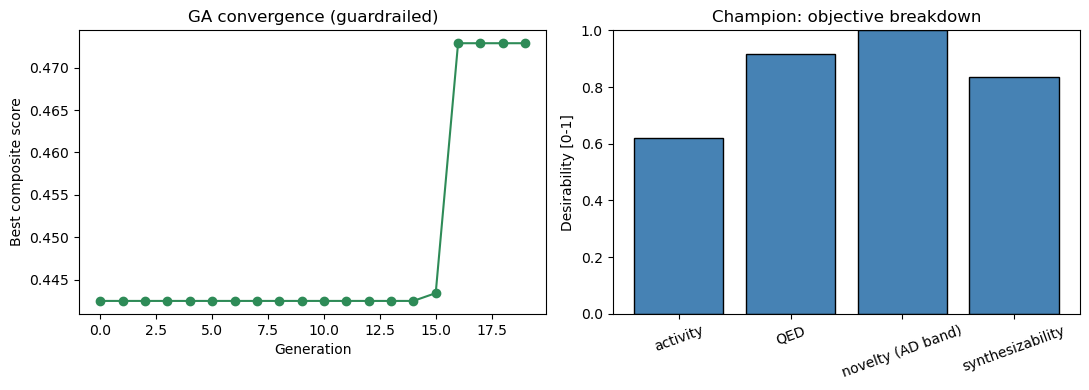

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(len(history)), history, marker="o", color="seagreen")
axes[0].set_xlabel("Generation"); axes[0].set_ylabel("Best composite score")
axes[0].set_title("GA convergence (guardrailed)")

x = featurize_one(best)
comps = {
    "activity": max(0.0, min(float(oracle.predict(x)[0]) / 10, 1.0)),
    "QED": qed(best),
    "novelty (AD band)": ad_desirability(ad_similarity(best)),
    "synthesizability": sa_desirability(best),
}
axes[1].bar(list(comps.keys()), list(comps.values()), color="steelblue", edgecolor="black")
axes[1].set_ylim(0, 1); axes[1].set_ylabel("Desirability [0-1]")
axes[1].set_title("Champion: objective breakdown")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

The fully guarded generator converges to a credible candidate: predicted pIC50 ~6.6, QED ~0.9, SA score ~2.8 (easy to synthesize) and Tanimoto ~0.35 (novel but in-domain). Remarkably, it rediscovers de novo the quinazoline core with a halogenated anilino substituent, the pharmacophore of real EGFR inhibitors such as gefitinib and erlotinib, which is a strong sanity check that the model and guardrails point in a chemically sensible direction.

| Fitness | pred. pIC50 | QED | Tanimoto (AD) | Issue |
|---|---|---|---|---|
| pIC50 only | 7.96 | 0.16 | 0.25 | reward hacking (out-of-domain, implausible) |
| + applicability domain (raw) | 6.42 | 0.77 | 1.00 | duplicate of a known active (no novelty) |
| + novelty band | 7.46 | 0.89 | 0.39 | balanced |
| + synthesizability + filters | 6.56 | 0.92 | 0.34 | credible, novel, synthesizable |

The convergence curve rises in the stepwise pattern typical of an elitist genetic algorithm, and the objective breakdown of the champion shows all criteria satisfied simultaneously, which is the point of the multiplicative score.

In [24]:
import sys
!{sys.executable} -m pip install py3Dmol

### 5.1 3D structure of the candidate

A 3D conformer of the best molecule is generated locally with RDKit (distance-geometry embedding followed by MMFF force-field optimization) and rendered interactively; no external service is required.

In [25]:
import py3Dmol
from rdkit.Chem import AllChem

m = Chem.AddHs(Chem.MolFromSmiles(best))     # ajoute les H pour une geometrie correcte
AllChem.EmbedMolecule(m, randomSeed=42)      # genere une conformation 3D
AllChem.MMFFOptimizeMolecule(m)              # optimise (champ de force MMFF)

view = py3Dmol.view(width=450, height=400)
view.addModel(Chem.MolToMolBlock(m), "mol")
view.setStyle({"stick": {}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [26]:
random.seed(42)
pop = random.sample(ref_smiles, 100)
n_gen, pop_size, n_keep = 20, 100, 20
traj = []
for gen in range(n_gen):
    parents = sorted(pop, key=multi_fitness, reverse=True)[:n_keep]
    b = parents[0]; xb = featurize_one(b)
    traj.append((gen, float(oracle.predict(xb)[0]), qed(b), sa_desirability(b)))
    children = []
    while len(children) < pop_size - n_keep:
        c = mutate(random.choice(parents), n_mut=random.randint(1, 3))
        if c is not None:
            children.append(c)
    pop = parents + children
best = sorted(pop, key=multi_fitness, reverse=True)[0]


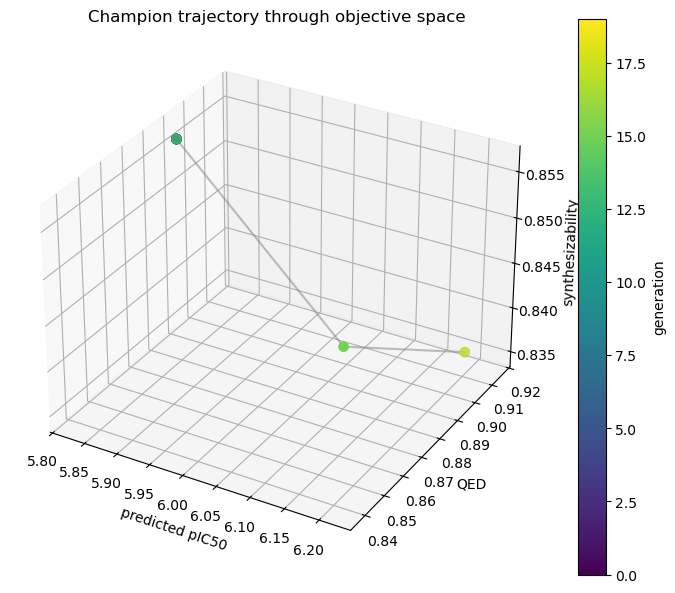

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

t = np.array(traj)
gens, pic50, q, sa = t[:, 0], t[:, 1], t[:, 2], t[:, 3]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(pic50, q, sa, color="gray", alpha=0.5)          # chemin
p = ax.scatter(pic50, q, sa, c=gens, cmap="viridis", s=45)
ax.set_xlabel("predicted pIC50")
ax.set_ylabel("QED")
ax.set_zlabel("synthesizability")
ax.set_title("Champion trajectory through objective space")
fig.colorbar(p, label="generation")
plt.tight_layout(); plt.show()

## 6. A physical-viability guardrail (semi-empirical quantum chemistry)

All previous guardrails are topological: they act on the 2D graph (fingerprints, QED, SA score, substructure alerts) and never check that the molecule is electronically sound. Here a semi-empirical quantum method (GFN2-xTB) relaxes the 3D geometry of each finalist and returns its HOMO-LUMO gap, used as a stability proxy: a very small gap flags a reactive or unstable species. Because xTB costs seconds per molecule, it is applied not inside the genetic algorithm but as a post-hoc re-ranking of the top-K survivors.

In [28]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from ase import Atoms
from ase.optimize import BFGS
from xtb.ase.calculator import XTB
from xtb.interface import Calculator, Param

BOHR = 1.8897259886
HARTREE_EV = 27.211386245988
EV_HARTREE = 1 / HARTREE_EV

def xtb_relax_and_gap(smiles, seed=42):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    if AllChem.EmbedMolecule(mol, randomSeed=seed) != 0:   # 3D embedding failed
        return None
    AllChem.MMFFOptimizeMolecule(mol)
    conf = mol.GetConformer()
    numbers = np.array([a.GetAtomicNum() for a in mol.GetAtoms()])

    # 1) geometry optimization with xtb (ASE works in Angstrom / eV)
    atoms = Atoms(numbers=numbers, positions=conf.GetPositions())
    atoms.calc = XTB(method="GFN2-xTB")
    BFGS(atoms, logfile=None).run(fmax=0.05, steps=250)
    energy_hartree = atoms.get_potential_energy() * EV_HARTREE

    # 2) HOMO-LUMO gap at the optimized geometry (native interface)
    positions_bohr = atoms.get_positions() * BOHR
    res = Calculator(Param.GFN2xTB, numbers, positions_bohr).singlepoint()
    occ = np.array(res.get_orbital_occupations())
    eps = np.array(res.get_orbital_eigenvalues())
    gap_eV = (eps[occ < 0.5].min() - eps[occ > 0.5].max()) * HARTREE_EV

    return {"energy_hartree": energy_hartree, "gap_eV": gap_eV}

print(xtb_relax_and_gap("CC(=O)Oc1ccccc1C(=O)O"))   # aspirin

{'energy_hartree': -39.63155676744016, 'gap_eV': np.float64(3.5566439779638315)}


In [29]:
def gap_desirability(gap_eV, low=1.0, high=3.0):
    if gap_eV<=low:
        return 0.0
    elif gap_eV>=high:
        return 1.0
    else:
        return (gap_eV - low) / (high - low)

def physical_viability(smiles):
    res = xtb_relax_and_gap(smiles)   
    if res is None:                    
        return 0.0
    return gap_desirability(res["gap_eV"])

def safe_viability(smiles):
    try:
        return physical_viability(smiles)
    except Exception:
        return 0.0        

In [30]:
import pandas as pd

def rerank_with_xtb(population, k=20):
    # 1) unique canonical SMILES from the final GA population
    uniq = {}
    for smi in population:
        m = Chem.MolFromSmiles(smi)
        if m is not None:
            uniq[Chem.MolToSmiles(m)] = None      # canonical key -> dedup
    # 2) keep the K best by the fast composite score
    cands = sorted(uniq.keys(), key=multi_fitness, reverse=True)[:k]

    # 3) expensive xtb pass ONLY on those K finalists
    rows = []
    for smi in cands:
        fit = multi_fitness(smi)
        try:
            res = xtb_relax_and_gap(smi)          # run xtb ONCE per molecule
        except Exception:
            res = None
        if res is None:
            gap, viab = None, 0.0                  # xtb failed -> non-viable
        else:
            gap = res["gap_eV"]
            viab = gap_desirability(gap)
        rows.append({
            "smiles": smi,
            "multi_fitness": round(fit, 3),
            "gap_eV": round(gap, 2) if gap is not None else None,
            "viability": round(viab, 3),
            "final_score": round(fit * viab, 3),
        })

    return pd.DataFrame(rows).sort_values("final_score", ascending=False).reset_index(drop=True)

ranked = rerank_with_xtb(pop, k=20)
ranked

,smiles,multi_fitness,gap_eV,viability,final_score
0,CCNC(=O)N(C)Cc1ccc(Nc2ccc(OC)cc2C)nc1,0.438,3.16,1.000,0.438
1,Cc1cccc2c1CCN2CN(C)c1nc(N2CCOCC2)cc(=O)[nH]1,0.437,3.40,1.000,0.437
2,CCCOC1Cc2cnc(Nc3ccc(OC)cc3C)cc21,0.421,3.28,1.000,0.421
3,Cc1cccc2c1CCN2C(=O)Cc1nc(N2CCOCC2)cc(=O)[nH]1,0.428,2.95,0.975,0.418
4,CCCNC(=O)N1C=CN=C(Nc2ccc(OC)cc2C)CC1,0.417,2.75,0.874,0.364
5,CN1CCN(C(=O)c2ccc(Nc3nccc(C4CCN4)n3)cc2)CC1,0.428,2.52,0.761,0.326
6,Cc1cccc2c1CCN2C(=O)c1nc(N2CCOCC2)cc(=O)[nH]1,0.429,2.41,0.703,0.302
7,O=C(NCCc1ccccc1)c1nc(N2CCOCC2)cc(=O)[nH]1,0.443,2.35,0.674,0.299
8,O=C(c1nc(N2CCOCC2)cc(=O)[nH]1)N1CCc2ccccc21,0.428,2.29,0.646,0.277
9,C=CC=C1C=C(C)N1C(=O)c1nc(N2CCOCC2)cc(=O)[nH]1,0.383,2.44,0.719,0.276


In [36]:
import py3Dmol
from rdkit.Chem import AllChem

smi = ranked.iloc[0]["smiles"]                # best candidate after xtb re-ranking
m = Chem.AddHs(Chem.MolFromSmiles(smi))       # explicit H for a correct geometry
AllChem.EmbedMolecule(m, randomSeed=42)       # 3D conformer
AllChem.MMFFOptimizeMolecule(m)               # force-field relaxation

print("SMILES:", smi)
view = py3Dmol.view(width=450, height=400)
view.addModel(Chem.MolToMolBlock(m), "mol")
view.setStyle({"stick": {}})
view.zoomTo()
view.show()

SMILES: CCNC(=O)N(C)Cc1ccc(Nc2ccc(OC)cc2C)nc1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from meeko import MoleculePreparation, PDBQTWriterLegacy
from vina import Vina

# --- Box center: computed ONCE from the co-crystal ligand (reused for all molecules) ---
_coords = [[float(l[30:38]), float(l[38:46]), float(l[46:54])]
           for l in open("../docking/ligand_ref.pdb") if l.startswith(("ATOM", "HETATM"))]
BOX_CENTER = list(np.mean(_coords, axis=0))
BOX_SIZE = [22.5, 22.5, 22.5]
RECEPTOR = "../docking/egfr.pdbqt"

def smiles_to_pdbqt(smiles, seed=42):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    m = Chem.AddHs(m)
    if AllChem.EmbedMolecule(m, randomSeed=seed) != 0:   # 3D embedding failed
        return None
    AllChem.MMFFOptimizeMolecule(m)
    pdbqt, ok, err = PDBQTWriterLegacy.write_string(MoleculePreparation().prepare(m)[0])
    return pdbqt if ok else None

def dock_score(smiles):
    """Best Vina affinity in kcal/mol (more negative = stronger binding). None on failure."""
    pdbqt = smiles_to_pdbqt(smiles)
    if pdbqt is None:
        return None
    v = Vina(sf_name="vina", verbosity=0)
    v.set_receptor(RECEPTOR)
    v.compute_vina_maps(center=BOX_CENTER, box_size=BOX_SIZE)
    v.set_ligand_from_string(pdbqt)
    v.dock(exhaustiveness=8, n_poses=5)
    return v.energies()[0][0]

print("gefitinib:", round(dock_score("COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1"), 2))
print("aspirin:  ", round(dock_score("CC(=O)Oc1ccccc1C(=O)O"), 2))

## 7. Discussion

The experiment makes a single point vivid: in generative design, the generator is the easy part; the scoring function and its guardrails are what determine whether the output is useful. An unconstrained optimizer reliably games a predictive model, and each guardrail added here fixed one failure mode while sometimes revealing the next (the applicability-domain reward, once unbounded, produced duplicates). The final multiplicative objective forces activity, drug-likeness, novelty, synthesizability and structural sanity to be satisfied together.

Important limitations remain. The predicted pIC50 is the opinion of an XGBoost model with modest accuracy (R² ~0.62 on EGFR); a high predicted value is a hypothesis to be tested by docking, synthesis and assay, not a validated activity. Rediscovering a known pharmacophore is reassuring but also shows the search stays close to known chemistry rather than proposing genuinely novel scaffolds. SELFIES guarantees validity, not synthesizability, and the SA score is only a heuristic.

The natural extensions follow the state of the art: replacing the SA score with a retrosynthesis-based accessibility score (RAscore) or full retrosynthetic planning for a true "probability that a synthetic route exists"; replacing the QSAR oracle with a physics-based affinity score or with docking; and moving to three-dimensional, structure-based generation inside the binding pocket. Each requires substantially heavier infrastructure and is left as future work.

## 8. Conclusion

A QSAR model was turned into a guarded molecular generator. The key lesson is methodological: optimizing a predictive model directly invites reward hacking, and honest generative design depends on a carefully constructed, multi-objective scoring function. With guardrails for applicability domain, novelty, drug-likeness, synthesizability and structural alerts, the generator produces credible, novel, synthesizable candidates that recover a known EGFR pharmacophore.

## References

[1] Olivecrona, M. et al. Molecular de-novo design through deep reinforcement learning. *J. Cheminform.* 9, 48 (2017).

[2] Krenn, M. et al. Self-referencing embedded strings (SELFIES): A 100% robust molecular string representation. *Mach. Learn. Sci. Technol.* 1, 045024 (2020).

[3] Ertl, P. & Schuffenhauer, A. Estimation of synthetic accessibility score of drug-like molecules. *J. Cheminform.* 1, 8 (2009).

[4] Bickerton, G.R. et al. Quantifying the chemical beauty of drugs (QED). *Nat. Chem.* 4, 90-98 (2012).

[5] Langevin, M. et al. Scaffold-constrained molecular generation. *J. Chem. Inf. Model.* 60, 5637-5646 (2020).

[6] Thakkar, A. et al. Retrosynthetic accessibility score (RAscore). *Chem. Sci.* 12, 3339-3349 (2021).